In [2]:
!pip install -q langchain_google_genai
!pip install -q langgraph
!pip install -q langgraph-checkpoint-sqlite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 6.3 MB/s eta 0:00:00


In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph.message import add_messages
from langchain_core.runnables import RunnableConfig
from dotenv import load_dotenv
import sqlite3
import uuid
import datetime

In [1]:
# Enter your Gemini API key here
import os
import getpass

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Gemini API key: ")
print("API Key set successfully!")

Enter your Gemini API key: ··········
API Key set successfully!


In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    prev_stats: list
    last_meal: dict


class Body_state(TypedDict):
    weight: float
    height: float
    age: int


class Calorie_state(TypedDict):
    calories: int
    protein: int
    carbs: int
    fat: int


##Resource setup##
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")
SYS_MESSAGE = SystemMessage(content="You are a helpful fitness coach that provides guidance and advice to users.")

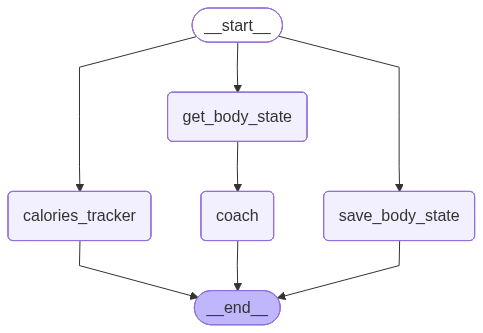

In [18]:




#########SQL lite database setup#########

DB_PATH = '/tmp/body_data.db'
CHECKPOINT_PATH = '/tmp/checkpointer.db'
CALORIE_DB_PATH = '/tmp/calorie_data.db'

conn = sqlite3.connect(database=CHECKPOINT_PATH, check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

body = sqlite3.connect(database=DB_PATH, check_same_thread=False)
body_cursor = body.cursor()

calorie = sqlite3.connect(database=CALORIE_DB_PATH, check_same_thread=False)
calorie_cursor = calorie.cursor()





def calories_tracker(state: ChatState, config: RunnableConfig) -> dict:
  SYS_MESSAGE = SystemMessage(content="You are a professional dietician. If the human message contains information about the food they ate, extract the nutritional info into a structured format.")
  structured_model = llm.with_structured_output(Calorie_state)

  user_input = state['messages'][-1]
  messages_for_llm = [SYS_MESSAGE] + [user_input]
  response = structured_model.invoke(messages_for_llm)

  if response:
      response['date'] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

      thread_id = str(config['configurable']['thread_id'])

      calorie_cursor.execute(f'''
          CREATE TABLE IF NOT EXISTS "{thread_id}" (
              datetime STRING PRIMARY KEY,
              calories INTEGER,
              protein INTEGER,
              carbs INTEGER,
              fat INTEGER
          )
      ''')

      calorie_cursor.execute(f'''
          INSERT INTO "{thread_id}" (datetime, calories, protein, carbs, fat)
          VALUES (?, ?, ?, ?, ?)
      ''', (response['date'], response.get('calories'), response.get('protein'), response.get('carbs'), response.get('fat')))

      calorie.commit()



      return {"last_meal" : {'calories': response.get('calories'),'protein' : response.get('protein'), 'carbs' : response.get('carbs'), 'fat' : response.get('fat')}}


#### graph node definition ####
def coach(state: ChatState) -> dict:
    prev_stats = state.get("prev_stats", [])
    calorie_stats = state.get("last_meal", {})


    context = f"\nUser's previous stats from database: {prev_stats}" if prev_stats else ""
    dynamic_sys_msg = SystemMessage(content=SYS_MESSAGE.content + context)
    last_meal= HumanMessage(content=f"User's last meal: {calorie_stats}")

    # Invoke the LLM with the new system message + last 10 conversation history
    messages_for_llm = [dynamic_sys_msg] + state["messages"][-10:] + [last_meal]
    response = llm.invoke(messages_for_llm)

    return {"messages": [response]}


def save_body_state(state: ChatState, config: RunnableConfig):
  SYS_MESSAGE = SystemMessage(content="You are a professional json parser. If Human message contains height, weight, age, body fat. Then parse it and return in this format {'weight': float, 'height': float, 'age': int, 'body_fat': float}")
  structured_model = llm.with_structured_output(Body_state)

  user_input = state['messages'][-1]
  messages_for_llm = [SYS_MESSAGE] + [user_input]
  response = structured_model.invoke(messages_for_llm)

  if response:
        response['id'] = str(uuid.uuid4())
        response['date'] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

        thread_id = str(config['configurable']['thread_id'])

        body_cursor.execute(f'''
            CREATE TABLE IF NOT EXISTS "{thread_id}" (
                id STRING PRIMARY KEY,
                datetime STRING,
                weight FLOAT,
                height FLOAT,
                age INTEGER
            )
        ''')

        body_cursor.execute(f'''
            INSERT INTO "{thread_id}" (id, datetime, weight, height, age)
            VALUES (?, ?, ?, ?, ?)
        ''', (response['id'], response['date'], response.get('weight'), response.get('height'), response.get('age')))

        body.commit()


  return {}


def get_body_state(state: ChatState, config: RunnableConfig):
    thread_id = str(config['configurable']['thread_id'])

    try:
        body_cursor.execute(f'''
            SELECT * FROM "{thread_id}"
            ORDER BY datetime DESC
            LIMIT 5
        ''')

        return {"prev_stats": body_cursor.fetchall()}

    except sqlite3.OperationalError:
        return {"prev_stats": []}





#####Graph setup#####
graph = StateGraph(ChatState)
graph.add_node("coach", coach)
graph.add_node("save_body_state", save_body_state)
graph.add_node("get_body_state", get_body_state)
graph.add_node("calories_tracker", calories_tracker)


graph.add_edge(START, "get_body_state")
graph.add_edge(START, "save_body_state")
graph.add_edge(START, "calories_tracker")
graph.add_edge("get_body_state", "coach")

graph.add_edge("save_body_state", END)
graph.add_edge("coach", END)

chatbot = graph.compile(checkpointer=checkpointer)
chatbot


In [19]:
CONFIG = {'configurable': {'thread_id': '1'}}

while True:
    user_input = input("User: ")

    if user_input.strip().lower() in ['exit', 'quit']:
        print("Exiting the chatbot. Goodbye!")
        break

    state_update = {"messages": [HumanMessage(content=user_input)]}
    response = chatbot.invoke(state_update, config=CONFIG)['messages'][-1].content[0]['text']
    print("Chatbot:", response)


User: User: Hi, I'm 87kg and 183cm, Today I ate 2 aloo paratha with 200g curd, then ate 100 panner in sahi paneer, also ate 1 milkcake piece and 1 laddo and ate 6 rotis
Chatbot: Hello! As your fitness coach, I’ve taken a look at the data you provided. At 87kg and 183cm, your body requires a strategic approach to nutrition depending on whether your goal is weight loss, maintenance, or muscle gain.

Here is a breakdown of your intake today:

### **Nutritional Summary**
*   **Total Calories:** ~2,150 kcal
*   **Protein:** 65g
*   **Carbs:** 280g
*   **Fat:** 85g

### **Coach’s Analysis**
1.  **Protein Intake:** For your body weight (87kg), 65g of protein is on the lower side. To maintain or build muscle, you should ideally aim for **1.2g to 1.6g of protein per kg of body weight** (approx. 105g–140g).
2.  **Carbohydrate Load:** Your meal consists of high-density carbs (Aloo paratha, 6 rotis, sweets). While energy is important, this high influx of simple sugars and refined flours can lead t

# Testing

In [ ]:
def save_body_state(user_input):
  SYS_MESSAGE = SystemMessage(content="You are a professional json parser. If Human message contains height, weight, age, body fat. Then parse it and return in this format {'weight': float, 'height': float, 'age': int, 'body_fat': float}")
  structured_model = llm.with_structured_output(Body_state)

  messages_for_llm = [SYS_MESSAGE] + [user_input]
  response = structured_model.invoke(messages_for_llm)
  response['id'] = str(uuid.uuid4())
  response['date'] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
  body_cursor.execute('''
    INSERT INTO dict_table (id, datetime, weight, height, age)
    VALUES (?, ?, ?, ?, ?)
  ''', (response['id'],response['date'], response['weight'], response['height'], response['age']))


  return response

a = input("User: ")
print(save_body_state(a))


User: I wiegh 87 kg and stand 190cm 
{'weight': 87, 'height': 190, 'age': 0, 'body_fat': 0, 'id': 'c3a170cd-ed81-4f66-80c2-6ff5b957ab1a', 'date': '2026-06-19 13:24:43'}


In [ ]:
state = {'messages': [HumanMessage(content='hi my name is Arjun, I weigh 87 kg and height is 183 cm and age is 21 years. I want to lose weight', additional_kwargs={}, response_metadata={}, id='5dd077c8-520c-4c45-bc02-c71d1cc8d8c0'), HumanMessage(content="Hi many name is Arjun. My weight is 87 kg and I'm 183 cm tall", additional_kwargs={}, response_metadata={}, id='dfaa6d61-5e51-4d7b-9dea-ae68b33a775a')]}
state['messages'][-1]


HumanMessage(content="Hi many name is Arjun. My weight is 87 kg and I'm 183 cm tall", additional_kwargs={}, response_metadata={}, id='dfaa6d61-5e51-4d7b-9dea-ae68b33a775a')

In [ ]:
body_cursor.execute(f'''
            SELECT * FROM '1'
            ORDER BY datetime DESC
            LIMIT 5
        ''')
body_cursor.fetchall()


[('b262a1b7-3e50-4401-a970-fa1a981abbb9',
  '2026-06-19 17:28:08',
  87.0,
  183.0,
  0)]

In [15]:
oh_yeah = {'weight': 87, 'height': 190, 'age': 0, 'body_fat': 0, 'id': 'c3a170cd-ed81-4f66-80c2-6ff5b957ab1a', 'date': '2026-06-19 13:24:43'}
oh_yess = [1,2,3,"aahha"]
wallah = oh_yess + [oh_yeah]
print(wallah)

[1, 2, 3, 'aahha', {'weight': 87, 'height': 190, 'age': 0, 'body_fat': 0, 'id': 'c3a170cd-ed81-4f66-80c2-6ff5b957ab1a', 'date': '2026-06-19 13:24:43'}]
